In [ ]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Read in the dataset
df = pd.read_csv('./car_sales_data.csv')
print(df.head())

         Date      Salesperson   Customer Name Car Make  Car Model  Car Year  \
0  2022-08-01  Monica Moore MD     Mary Butler   Nissan     Altima      2018   
1  2023-03-15     Roberto Rose  Richard Pierce   Nissan      F-150      2016   
2  2023-04-29     Ashley Ramos    Sandra Moore     Ford      Civic      2016   
3  2022-09-04   Patrick Harris    Johnny Scott     Ford     Altima      2013   
4  2022-06-16       Eric Lopez   Vanessa Jones    Honda  Silverado      2022   

   Sale Price  Commission Rate  Commission Earned  
0       15983         0.070495            1126.73  
1       38474         0.134439            5172.40  
2       33340         0.114536            3818.63  
3       41937         0.092191            3866.20  
4       20256         0.113490            2298.85  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500000 entries, 0 to 2499999
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date               object 
 1   Salesperson        object 
 2   Customer Name      object 
 3   Car Make           object 
 4   Car Model          object 
 5   Car Year           int64  
 6   Sale Price         int64  
 7   Commission Rate    float64
 8   Commission Earned  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 171.7+ MB
None


In [4]:
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


In [5]:
df = df.dropna(subset=["Sale Price", "Car Model"])

In [6]:
print(df.isnull().sum())

Date                 0
Salesperson          0
Customer Name        0
Car Make             0
Car Model            0
Car Year             0
Sale Price           0
Commission Rate      0
Commission Earned    0
dtype: int64


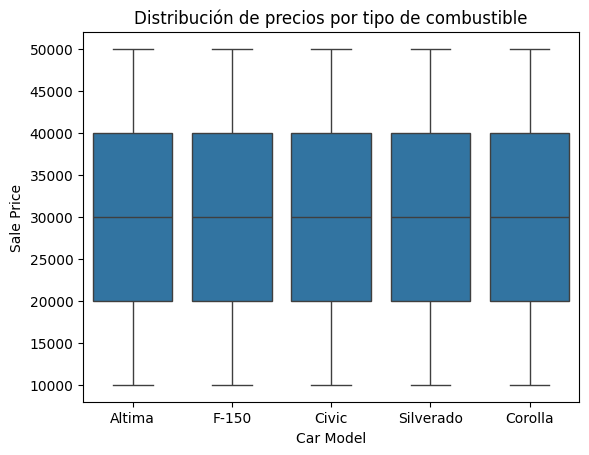

In [7]:
sns.boxplot(x="Car Model", y="Sale Price", data=df)
plt.title("Distribución de precios por tipo de combustible")
plt.show()

In [8]:
#limpiar valores extremos (outliers)
q_low = df["Sale Price"].quantile(0.01)
q_high = df["Sale Price"].quantile(0.99)
df = df[(df["Sale Price"] >= q_low) & (df["Sale Price"] <= q_high)]

Descripcion de las variables y datos:
-Identifica cuales son numericas y cuales son categoricas
-Estadistico descriptivo para variables numericas
-Estadistico descriptivo para variables categoricas

In [9]:
print("Tipos de variables en el DataFrame:")    #Identificar cuales son numericas y cuales son categoricas
print(df.dtypes)

Tipos de variables en el DataFrame:
Date                  object
Salesperson           object
Customer Name         object
Car Make              object
Car Model             object
Car Year               int64
Sale Price             int64
Commission Rate      float64
Commission Earned    float64
dtype: object


In [10]:
#Estadisticos descriptivos, solo para variables numericas(conteo, promedio, desviacion estandar, min, cuartil 1, 2(mediana) y 3, max)
pd.set_option("display.float_format", "{:,.2f}".format) #fuerza a mostrar los numeros con 2 decimales
print("\nEstadisticos descriptivos de variables numericas:")
print(df.describe())


Estadisticos descriptivos de variables numericas:
          Car Year   Sale Price  Commission Rate  Commission Earned
count 2,450,020.00 2,450,020.00     2,450,020.00       2,450,020.00
mean      2,016.00    30,012.41             0.10           3,000.96
std           3.74    11,314.23             0.03           1,461.95
min       2,010.00    10,402.00             0.05             521.17
25%       2,013.00    20,220.00             0.07           1,839.74
50%       2,016.00    30,006.00             0.10           2,743.84
75%       2,019.00    39,823.00             0.13           3,965.44
max       2,022.00    49,597.00             0.15           7,437.19


In [11]:
#Estadisticos descriptivos para variables categoricas(conteos, valores unicos, la moda(valor que mas se repite), freq(cantidad de la moda, frecuencia))
print("\nEstadisticos descriptivos de variables categoricas:")
print(df.describe(include=['object', 'category']))


Estadisticos descriptivos de variables categoricas:
              Date    Salesperson  Customer Name Car Make  Car Model
count      2450020        2450020        2450020  2450020    2450020
unique         366         513888         513566        5          5
top     2022-12-24  Michael Smith  Michael Smith    Honda  Silverado
freq          7006           1200           1145   490682     490792
